# EchoNet-Dynamic ED/ES Preprocessing Pipeline

Goal:
Extract ED and ES cardiac phases from EchoNet videos,
convert them into ML-ready tensors,
and create a reusable PyTorch Dataset pipeline.

In [1]:
import cv2
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from torchvision import transforms
from torch.utils.data import Dataset

# Load EchoNet-Dynamic Metadata

In [2]:
ECHONET_DIR = Path("../../data/raw/EchoNet-Dynamic")
filelist = pd.read_csv(ECHONET_DIR/"FileList.csv")
tracings = pd.read_csv(ECHONET_DIR/"VolumeTracings.csv")


In [3]:
filelist.head()


,FileName,EF,ESV,EDV,FrameHeight,FrameWidth,FPS,NumberOfFrames,Split
0,0X100009310A3BD7FC,78.498406,14.881368,69.210534,112,112,50,174,VAL
1,0X1002E8FBACD08477,59.101988,40.383876,98.742884,112,112,50,215,TRAIN
2,0X1005D03EED19C65B,62.363798,14.267784,37.909734,112,112,50,104,TRAIN
3,0X10075961BC11C88E,54.545097,33.143084,72.914210,112,112,55,122,TRAIN
4,0X10094BA0A028EAC3,24.887742,127.581945,169.855024,112,112,52,207,VAL


In [4]:
tracings.head()

,FileName,X1,Y1,X2,Y2,Frame
0,0X100009310A3BD7FC.avi,51.260417,15.348958,64.932292,69.125000,46
1,0X100009310A3BD7FC.avi,50.037611,17.167841,53.367222,16.321330,46
2,0X100009310A3BD7FC.avi,49.157378,20.407629,57.090549,18.390722,46
3,0X100009310A3BD7FC.avi,48.538173,23.581055,59.997339,20.667707,46
4,0X100009310A3BD7FC.avi,47.918968,26.754480,62.904129,22.944693,46


# Image Preprocessing Pipeline

Frames are resized to 224×224 and normalized
using ImageNet statistics for compatibility
with pretrained CNN architectures.

In [5]:
# Image preprocessing pipeline applied to every extracted frame
echo_tfm = transforms.Compose([
    # Convert OpenCV NumPy image into PIL format
    # because torchvision transforms work efficiently with PIL images
    transforms.ToPILImage(),
    # Resize all cardiac frames to a fixed resolution
    # so every input tensor has the same shape for CNN models
    transforms.Resize((224, 224)),
    # Convert image into PyTorch tensor
    # Shape changes from (H,W,C) → (C,H,W)
    # Pixel values also scale from [0,255] → [0,1]
    transforms.ToTensor(),
    # Normalize tensor using ImageNet statistics
    # Helps pretrained CNN models generalize better
    # and stabilizes training
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# Helper Functions

## EF Severity Mapping

Convert continuous ejection fraction (EF) values
into categorical severity labels.

- EF ≥ 50 → Normal
- EF 40–49 → Mild
- EF < 40 → Severe

In [6]:
def ef_to_severity(ef):
    if ef >= 50:
        return 0   # Normal
    elif ef >= 40:
        return 1   # Mild
    else:
        return 2   # Severe

## Extract Annotated Frames

EchoNet provides annotated cardiac phases
inside `VolumeTracings.csv`.

This function retrieves the unique annotated
frame indices for a given video.

In [7]:
def get_annotated_frames(video_name,tracings):
    video_tracings = tracings[tracings["FileName"] ==video_name]
    frames = sorted(video_tracings["Frame"].unique())

    if len(frames)>2:
        raise ValueError(f"{video_name} has {len(frames)} annotated frames: {frames}")

    return frames

## Read and Preprocess Frames

This function:
- loads requested video frames
- converts BGR → RGB
- resizes frames to 224×224
- normalizes using ImageNet statistics
- converts frames into PyTorch tensors

In [8]:
def read_two_frames(video_path, frame_indices):
     # Open the echo video using OpenCV
    # video_path is converted to string because OpenCV expects string paths
    cap = cv2.VideoCapture(str(video_path))
    # Store transformed ED and ES frame tensors
    frames = []

    for idx in frame_indices:
         # Jump directly to the required frame
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame = cap.read()

        if not ok:
            cap.release()
            raise RuntimeError(f"Could not read frame {idx} from {video_path}")

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(echo_tfm(frame_rgb))

    cap.release()

    return torch.stack(frames)

## Why contourArea() was not used

`cv2.contourArea()` expects ordered contour points.
However, `np.unique()` may reorder tracing points,
leading to unstable contour area estimation.

Hence, total tracing-line-length estimation
was used instead.

In [9]:
# def contour_area_for_frame(video_name, frame_idx, tracings):
#     frame_points = tracings[
#         (tracings["FileName"] == video_name) &
#         (tracings["Frame"] == frame_idx)
#     ]

#     points = []

#     for _, r in frame_points.iterrows():
#         points.append([r["X1"], r["Y1"]])
#         points.append([r["X2"], r["Y2"]])

#     points = np.array(points, dtype=np.float32)

#     # remove duplicate points
#     points = np.unique(points, axis=0)

#     # contour area
#     area = cv2.contourArea(points)

#     return area

The alternative approach uses total tracing-line length.
ED frames generally have higher total tracing length than ES frames.

## ED/ES Frame Detection using Tracing Length

The contour-area approach produced unstable results
because contour points were not guaranteed to remain ordered.

Instead, total tracing-line length is used
as an approximate estimate of ventricle size.

- Larger tracing length → ED frame
- Smaller tracing length → ES frame

In [10]:
def get_ed_es_frames_by_tracing_count(video_name, tracings):
     # Get annotated cardiac frames for the given video
    # EchoNet usually provides two annotated phases:
    # ED (expanded ventricle) and ES (contracted ventricle)
    frames = get_annotated_frames(video_name, tracings)

    lengths = {}

    for f in frames:
        frame_points = tracings[
            (tracings["FileName"] == video_name) &
            (tracings["Frame"] == f)
        ]

        # approximate ventricle size using average line length
        # Compute length of every tracing line segment
        # using Euclidean distance formula
        line_lengths = np.sqrt(
            (frame_points["X2"] - frame_points["X1"])**2 +
            (frame_points["Y2"] - frame_points["Y1"])**2
        )
        # Total tracing length is used as an approximate
        # estimate of ventricle size

        lengths[f] = line_lengths.sum()

    ed_frame = max(lengths, key=lengths.get)
    es_frame = min(lengths, key=lengths.get)

    return ed_frame, es_frame

# ED/ES Visualization

In [11]:
# Sample video used for visualization and pipeline testing
row = filelist.iloc[0]

base_name = row["FileName"]
video_name = base_name + ".avi"
video_path = ECHONET_DIR / "Videos" / video_name

ed_frame, es_frame = get_ed_es_frames_by_tracing_count(video_name, tracings)

ed_es_tensor = read_two_frames(video_path, [ed_frame, es_frame])

print("Video:", video_name)
print("ED:", ed_frame)
print("ES:", es_frame)
print("Tensor shape:", ed_es_tensor.shape)

Video: 0X100009310A3BD7FC.avi
ED: 46
ES: 61
Tensor shape: torch.Size([2, 3, 224, 224])


In [12]:
def draw_contour(frame_rgb, video_name, frame_idx, tracings):

    frame_points = tracings[
        (tracings["FileName"] == video_name) &
        (tracings["Frame"] == frame_idx)
    ]

    plt.imshow(frame_rgb)

    for _, row in frame_points.iterrows():

        plt.plot(
            [row["X1"], row["X2"]],
            [row["Y1"], row["Y2"]],
            color="red"
        )

    plt.axis("off")

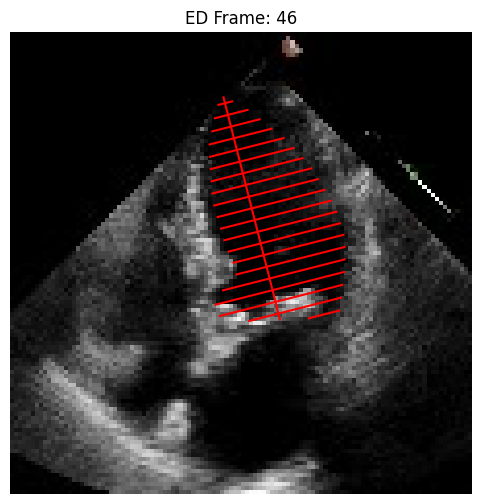

In [13]:
cap = cv2.VideoCapture(str(video_path))

cap.set(cv2.CAP_PROP_POS_FRAMES, ed_frame)
ok, frame = cap.read()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))

draw_contour(frame_rgb, video_name, ed_frame, tracings)

plt.title(f"ED Frame: {ed_frame}")

plt.show()

cap.release()

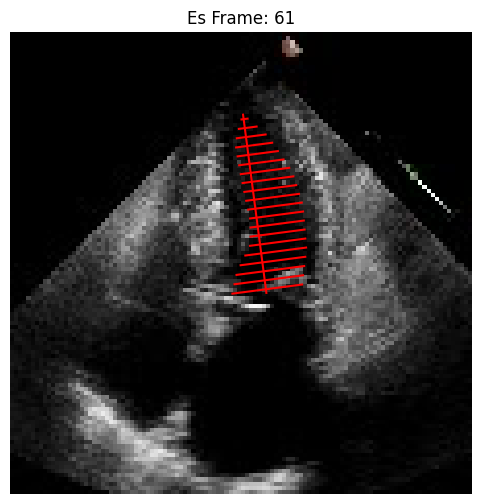

In [14]:
cap_2 = cv2.VideoCapture(str(video_path))

cap_2.set(cv2.CAP_PROP_POS_FRAMES, es_frame)
ok, frame2 = cap_2.read()

frame_rgb_2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))

draw_contour(frame_rgb_2, video_name, es_frame, tracings)

plt.title(f"Es Frame: {es_frame}")

plt.show()

cap.release()

# PyTorch Dataset Pipeline

In [15]:
# Custom PyTorch Dataset for EchoNet-Dynamic preprocessing pipeline
class EchoDataset(Dataset):

    def __init__(self, filelist, tracings, root_dir):

        self.filelist = filelist
        self.tracings = tracings
        self.root_dir = root_dir

    def __len__(self):

        return len(self.filelist)

    def __getitem__(self, idx):

        row = self.filelist.iloc[idx]

        video_name = row["FileName"] + ".avi"

        video_path = self.root_dir / "Videos" / video_name

        ef = row["EF"]

        severity = ef_to_severity(ef)

        ed_frame, es_frame = get_ed_es_frames_by_tracing_count(
            video_name,
            self.tracings
        )

        tensor = read_two_frames(
            video_path,
            [ed_frame, es_frame]
        )

        return {
            "video_name": video_name,
            "tensor": tensor,
            "ef": ef,
            "severity": severity
        }

In [16]:
dataset = EchoDataset(
    filelist,
    tracings,
    ECHONET_DIR
)

In [17]:
sample = dataset[0]

print(sample["video_name"])
print(sample["tensor"].shape)
print(sample["ef"])
print(sample["severity"])

0X100009310A3BD7FC.avi
torch.Size([2, 3, 224, 224])
78.49840597
0


# Week 1 Summary

Completed:
- ED/ES extraction
- contour visualization
- tensor preprocessing
- severity mapping
- PyTorch Dataset pipeline

Output:
Each dataset sample returns:
{
    tensor,
    ef,
    severity
}